In [1]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

In [16]:
n_probes = 30
n_channels = 64

sim_dir = '/home/kedoxey/CRCNS/PyramidalCellSimulations/models/NEURON/NMLCL000073-NEURON/output/LFP_basal'
sim_label = f'LFP_basal-0nA-50Ex1-1x40Hz-{n_probes}x{n_channels}lp-probes'


eap_file_path = os.path.join(sim_dir, sim_label, f'{sim_label}-simulated_eaps.pkl')
probe_file_path = os.path.join(sim_dir, sim_label, f'{sim_label}-recording_probe_locs.pkl')

In [17]:
data_df = pd.read_pickle(eap_file_path)
probes = np.array(pd.read_pickle(probe_file_path))

In [4]:
num_probes, num_channels, _ = np.shape(probes)

probe_nums = []
channel_nums = []

for i, row in data_df.iterrows():
    probe_nums.append(int(i/num_channels))
    channel_nums.append(i%num_channels)

data_df['probe_num'] = probe_nums
data_df['channel_num'] = channel_nums

In [5]:
data_df.head()

,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[8.925389294144767e-05, 8.925404212240582e-05,...",12.137976,-58.300813,11.357892,1147,True,408.071733,0,0
1,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[9.33024612960276e-05, 9.33026444339924e-05, 9...",12.137976,-48.300813,11.357892,1147,True,408.071733,0,1
2,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[9.746779477352292e-05, 9.746801458655417e-05,...",12.137976,-38.300813,11.357892,1147,True,408.071733,0,2
3,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[0.00010167280875951102, 0.0001016730677653627...",12.137976,-28.300813,11.357892,1147,True,408.071733,0,3
4,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[0.00010580130578616394, 0.0001058016059544021...",12.137976,-18.300813,11.357892,1147,True,408.071733,0,4


In [6]:
def find_n_closest_probes(probes, n_closest, max_channel_i = 25):
    
    num_probes, _, _ = np.shape(probes)
    distances = []
    
    for i in range(num_probes):
        probe = probes[i,:,:]
        x,y,z = probe[max_channel_i]
        dist = np.sqrt(x**2+y**2+z**2)
        distances.append(dist)
        
    print('Closest probe found at %s microns...'%np.min(distances))
    return np.argsort(distances)[:n_closest]  # np.argmin(distances)

def find_n_farthest_probes(probes, n_farthest, max_channel_i = 25):
    
    num_probes, _, _ = np.shape(probes)
    distances = []
    
    for i in range(num_probes):
        probe = probes[i,:,:]
        x,y,z = probe[max_channel_i]
        dist = np.sqrt(x**2+y**2+z**2)
        distances.append(dist)
        
    print('Farthest probe found at %s microns...'%np.max(distances))
    return np.argsort(distances)[-n_farthest:]  # np.argmax(distances)

In [7]:
closest_probe = find_n_closest_probes(probes, 1, max_channel_i=6)
closest_probe_df = data_df[data_df.probe_num.isin(closest_probe)]
closest_probe_df.head()

Closest probe found at 16.70985905589997 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[8.925389294144767e-05, 8.925404212240582e-05,...",12.137976,-58.300813,11.357892,1147,True,408.071733,0,0
1,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[9.33024612960276e-05, 9.33026444339924e-05, 9...",12.137976,-48.300813,11.357892,1147,True,408.071733,0,1
2,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[9.746779477352292e-05, 9.746801458655417e-05,...",12.137976,-38.300813,11.357892,1147,True,408.071733,0,2
3,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[0.00010167280875951102, 0.0001016730677653627...",12.137976,-28.300813,11.357892,1147,True,408.071733,0,3
4,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[0.00010580130578616394, 0.0001058016059544021...",12.137976,-18.300813,11.357892,1147,True,408.071733,0,4


In [8]:
waves = []
for _, row in closest_probe_df.iterrows():

    ve = row.ve
    amp = np.max(ve) - np.min(ve)

    norm_ve = np.divide(ve, amp)

    wave = list(norm_ve)


    waves.append(wave)

In [9]:
icefire_cmap = sns.color_palette("icefire_r", as_cmap=True)

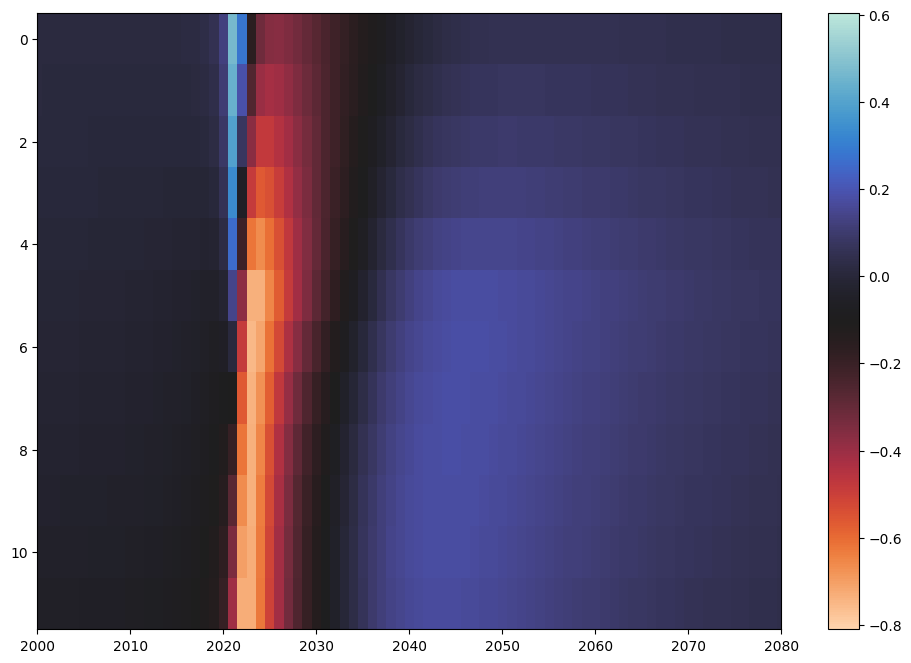

In [10]:
fig, axs = plt.subplots(1,1, figsize=(12,8))
im = axs.imshow(waves, interpolation='nearest', aspect='auto', cmap=icefire_cmap)
axs.set_xlim([2000,2080])
fig.colorbar(im)

In [37]:
farthest_probe = find_n_farthest_probes(probes, 1, max_channel_i=6)
farthest_probe_df = data_df[data_df.probe_num.isin(farthest_probe)]
farthest_probe_df.head()

Farthest probe found at 20.185846497028646 microns...


,Model_ID,t,vm,ve,x_bar,y_bar,z_bar,num_spikes,did_spike,first_spkt,probe_num,channel_num
0,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[8.925389294144767e-05, 8.925404212240582e-05,...",12.137976,-58.300813,11.357892,1147,True,408.071733,0,0
1,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[9.33024612960276e-05, 9.33026444339924e-05, 9...",12.137976,-48.300813,11.357892,1147,True,408.071733,0,1
2,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[9.746779477352292e-05, 9.746801458655417e-05,...",12.137976,-38.300813,11.357892,1147,True,408.071733,0,2
3,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[0.00010167280875951102, 0.0001016730677653627...",12.137976,-28.300813,11.357892,1147,True,408.071733,0,3
4,NMLCL000073,"[400.00000000002245, 400.1000000000225, 400.20...","[-77.18251311792972, -77.18252912640395, -77.1...","[0.00010580130578616394, 0.0001058016059544021...",12.137976,-18.300813,11.357892,1147,True,408.071733,0,4


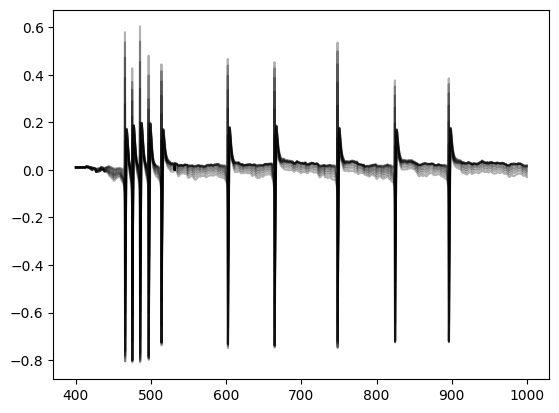

In [38]:
fig, axs = plt.subplots(1,1)

for _, row in closest_probe_df.iterrows():

    t = row.t[:len(row.ve)]
    ve = row.ve
    amp = np.max(ve) - np.min(ve)

    norm_ve = np.divide(ve, amp)

    axs.plot(t, norm_ve, 'k', alpha=0.3)


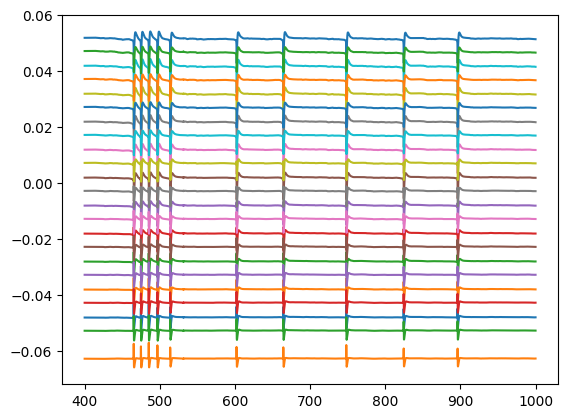

In [39]:
fig, axs = plt.subplots(1,1)

for idx, row in data_df.iterrows():
    if idx == 0:
        continue
    temp = 5
    axs.plot(row.t[:len(row.ve)], row.ve+row.y_bar/1000)

# x_bars = np.unique(data_df.x_bar)
# axs.set_yticks(x_bars/1000)
# axs.set_yticklabels(np.round(x_bars,2));

### Normalize data

<!-- ### Plot heatmap
https://datascience.stackexchange.com/questions/93941/create-a-continuous-heatmap
 -->
